1. One Change in the structure, I will be using just a single same word_to_index which contains both english and french words

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("/kaggle/input/datasets/rajpulapakura/english-to-french-small-dataset/english_french.csv")
df = df.sample(frac=1).reset_index(drop=True)

In [3]:
len_slice = (int)(0.8* len(df))
X_train= df['English'].iloc[:len_slice]
X_test= df['English'].iloc[len_slice:]

y_train= df['French'].iloc[:len_slice]
y_test= df['French'].iloc[len_slice:]

In [4]:
import nltk
from nltk.tokenize import word_tokenize

In [5]:
def mod(X):
    mod1= [text.lower() for text in X]
    mod2= [word_tokenize(x) for x in mod1]
    
    return mod1,mod2

In [6]:
X_modded, X_mod= mod(X_train)
Y_modded, Y_mod= mod(y_train)

Y_mod= [['<SOS>'] + token + ['<EOS>'] for token in Y_mod]

In [7]:
max_len_x = max(len(sentence) for sentence in X_mod)
max_len_y = max(len(sentence) for sentence in Y_mod)

print(max_len_x)
print(max_len_y)

78
79


In [8]:
# tokenize the words ->
word_to_index= {}
word_to_index['<PAD>']= 0
word_to_index['<UNK>']= 1
word_to_index['<SOS>']= 2
word_to_index['<EOS>']= 3
index=4

for sentence in X_mod:
    for word in sentence:
        if word not in word_to_index:
            word_to_index[word] = index
            index += 1

for sentence in Y_mod:
    for word in sentence:
        if word not in word_to_index:
            word_to_index[word] = index
            index += 1

In [9]:
def sentences_to_indices(X, word_to_index, max_len):

    m = len(X)
    X_indices = np.zeros((m, max_len))

    for i in range(m):
        j = 0
        for w in X[i]:
            if(j>=max_len):
                break
            X_indices[i, j] = word_to_index.get(w, 1)  
            j = j + 1
    return X_indices

In [10]:
X_indices= sentences_to_indices(X_mod, word_to_index, max_len_x)
Y_indices= sentences_to_indices(Y_mod, word_to_index, max_len_y)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

In [12]:
X_tensor= torch.tensor(X_indices,dtype=torch.long)
y_tensor= torch.tensor(Y_indices,dtype= torch.long)
batch_size=64

# data loader
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(X_tensor,y_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [13]:
for x,y in loader:
    input_to_decoder= torch.cat((x,y),dim=-1)
    print(input_to_decoder.shape)
    break

torch.Size([64, 157])


In [14]:
X_tensor.shape

torch.Size([183842, 78])

In [15]:
y_tensor.shape

torch.Size([183842, 79])

In [16]:
emb_dim= 256
hidden_dim= 256
heads= 4
vocab_size= len(word_to_index)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_hist= []
criterion = nn.CrossEntropyLoss(ignore_index=word_to_index['<PAD>'])


<h4>Make some methods </h4>

In [26]:
class convert(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.Wq= nn.Parameter(torch.randn(dim,dim,device=device)* np.sqrt(2.0/(dim)))
        self.Wk= nn.Parameter(torch.randn(dim,dim,device=device)* np.sqrt(2.0/(dim)))
        self.Wv= nn.Parameter(torch.randn(dim,dim,device=device)* np.sqrt(2.0/(dim)))

    def forward(self, X):
        Q_list= [self.Wq@(x.T) for x in X]
        Q= torch.stack(Q_list)
        K_list= [self.Wk@(x.T) for x in X]
        K= torch.stack(K_list)
        V_list= [self.Wv@(x.T) for x in X]
        V= torch.stack(V_list)

        return Q,K,V
        

In [27]:
class FFN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        d_ff= 4*dim
        self.W_a= nn.Parameter(torch.randn(dim, d_ff,device=device)*np.sqrt(2.0/dim))
        self.W_b= nn.Parameter(torch.randn(d_ff, dim,device=device)*np.sqrt(2.0/d_ff))
        self.B_a= nn.Parameter(torch.randn(d_ff,device=device))
        self.B_b= nn.Parameter(torch.randn(dim,device=device))
        self.gelu= nn.GELU()

    def forward(self, x):
        temp1= (x@self.W_a) + self.B_a
        temp2= self.gelu(temp1)
        temp3= (temp2@self.W_b) + self.B_b
        return temp3

In [20]:
def LayerNorm(x):
    # shape (B, T, dim)
    fac= 1e-5
    mean= torch.mean(x, dim= -1, keepdim=True)
    var= torch.std(x, dim=-1, correction=False, keepdim=True)

    std= (var+fac)**0.5
    x_norm= (x-mean)/std

    return x_norm

In [21]:
def fn_even(j,i):
    temp= j/(10000**((2*i)/emb_dim))
    return np.sin(temp)

In [22]:
def fn_odd(j,i):
    temp= j/(10000**((2*i - 1)/emb_dim))
    return np.cos(temp)

In [23]:
def pos_enc(T):

    pos_encoding= torch.zeros(T,emb_dim, device=device)
    
    for j in range(T):
        for i in range(emb_dim):
            # check even odd
            if(i&1):
                pos_encoding[j][i]= fn_odd(j,i)
            else:
                pos_encoding[j][i]= fn_even(j,i)

    
    return pos_encoding

In [37]:
class decoder_model(nn.Module):
    def __init__(self,vocab_size, emb_dim, max_len_x, max_len_y, heads):
        
        super(decoder_model, self).__init__()
        self.embedding = nn.Parameter(torch.randn(vocab_size,emb_dim))
        self.max_len_y = max_len_y
        self.heads= heads
        T= max_len_x + max_len_y -1
        self.pos_encoding= pos_enc(T)
        self.conv= convert(emb_dim)
        self.ffn= FFN(emb_dim)

        # making the masking matrix
        self.M= torch.zeros(T,T,device=device)
        for i in range(T):
            for j in range(T):
                if(i<j):
                    self.M[i][j]= float('-inf')

        # self.dropout = nn.Dropout(0.2)
        
    def forward(self,x):

        x= self.embedding[x]
        # shape (B, T, Dim)

        x= x+ self.pos_encoding
        # Pre layer Normalization

        x_ln= LayerNorm(x)
        # -------------------STEP 4 DONE----------------------
        
        Q,K,V= self.conv.forward(x_ln)
        # shape (B, Dim, T)
        
        batch_size= x.shape[0]
        T= x.shape[1]
        dimension= x.shape[2]
        d_block= (int)(dimension/self.heads)

        Q= torch.reshape(Q, (batch_size, self.heads, d_block, T))
        K= torch.reshape(K, (batch_size, self.heads, d_block, T))
        V= torch.reshape(V, (batch_size, self.heads, d_block, T))
        # shape (B, H, D, T)

        div= d_block**0.5

        z_list= []
        for i in range(self.heads):
            q= Q[:,i,:,:]
            k= K[:,i,:,:]
            v= V[:,i,:,:]

            temp1= torch.matmul(q.transpose(1,2),k)
            temp2= temp1 / div
            temp3= torch.softmax(temp2 + self.M, dim=-1)
            temp4= torch.matmul(temp3, v.transpose(1,2))
            z_list.append(temp4)

        z_temp1= torch.cat(z_list, dim=-1)
        # shape (B, T, Dim)

        z_temp1= x+ z_temp1
        # ---------------STEP 1 ENDS HERE--------------------

        z_ln_temp1= LayerNorm(z_temp1)
        z_temp2= z_temp1 + self.ffn.forward(z_ln_temp1) 
        # ---------------STEP 2 ENDS HERE--------------------
        # ---------------STEP 3 ENDS HERE--------------------

        z= z_temp2@((self.embedding).T)
        # ---------------STEP 5 ENDS HERE--------------------
        
        return z

    # def translate(self,x):
    #     x=self.embedding_x(x)
    #     _,(h_n,c_n)= self.encoder(x)
    #     # small task to create an emb for this SOS and EOS ie a 64,max_len_x tensor = [2,0,0,.....] and [3,0,0,.....]

    #     batch_size= x.shape[0]
    #     start= torch.zeros((batch_size,1),dtype= torch.long, device= x.device)
    #     start += 2;
    #     end= torch.zeros((batch_size,1),dtype=torch.long,device= x.device)
    #     end += 3

    #     decoder_input= self.embedding_y(start)
    #     target= end
    #     preds= []

    #     output,(h_n,c_n)= self.decoder(decoder_input,(h_n,c_n))
    #     output_01= self.fc(output)
    #     output_02= output_01.argmax(2)
    #     preds.append(output_01)

    #     for _ in range(self.max_len_y):

    #         if(output_02 == end).all():
    #             break
            
    #         decoder_input= self.embedding_y(output_02)
    #         output,(h_n,c_n)= self.decoder(decoder_input,(h_n,c_n))
    #         output_01= self.fc(output)
    #         output_02= output_01.argmax(2)
    #         preds.append(output_01)

    #     preds= torch.cat(preds,dim=1)
    #     return preds

In [38]:
model= decoder_model(vocab_size, emb_dim, max_len_x, max_len_y, heads).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [39]:
for x,y in loader:

    x= torch.cat((x,y),dim=-1)
    x_input= x[:,:-1].to(device)
    pred= model(x_input)
    print(pred.shape)
    break

torch.Size([64, 156, 43607])


In [40]:
def train(model, dataloader, epochs=10):

    for epoch in range(epochs):

        total_loss=0
        num_batches= 0
        model.train()
        for x,y in dataloader:

            x_edit= torch.cat((x,y),dim=-1)  
            x_input= x_edit[:,:-1].to(device)
            y_input= x_edit[:,1:].reshape(-1).to(device)
            
            optimizer.zero_grad()
            outputs = model(x_input)
            outputs = outputs.reshape(-1, outputs.shape[-1])

            loss = criterion(outputs, y_input)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        print(f"Epoch {epoch+1}, Loss: {total_loss/num_batches:.4f}")
        loss_hist.append(total_loss/num_batches)
        torch.save(model.state_dict(),f'model_epoch{epoch+1}.pth')

In [42]:
train(model, loader, 5)

Epoch 1, Loss: 2.2993
Epoch 2, Loss: 2.2207
Epoch 3, Loss: 2.1516
Epoch 4, Loss: 2.0906
Epoch 5, Loss: 2.0349


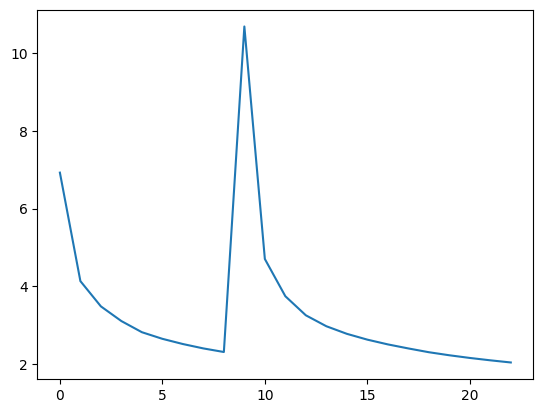

In [43]:
plt.plot(loss_hist)
plt.show()